# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [2]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

Data successfully loaded and processed.


In [3]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 6
- Unchanged feature creation functions: 6 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats

Total Created Features:  245


## 2 Split Data

In [4]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 9000
No validation set created.
Test set size: 3000


## 3. Feature Selection

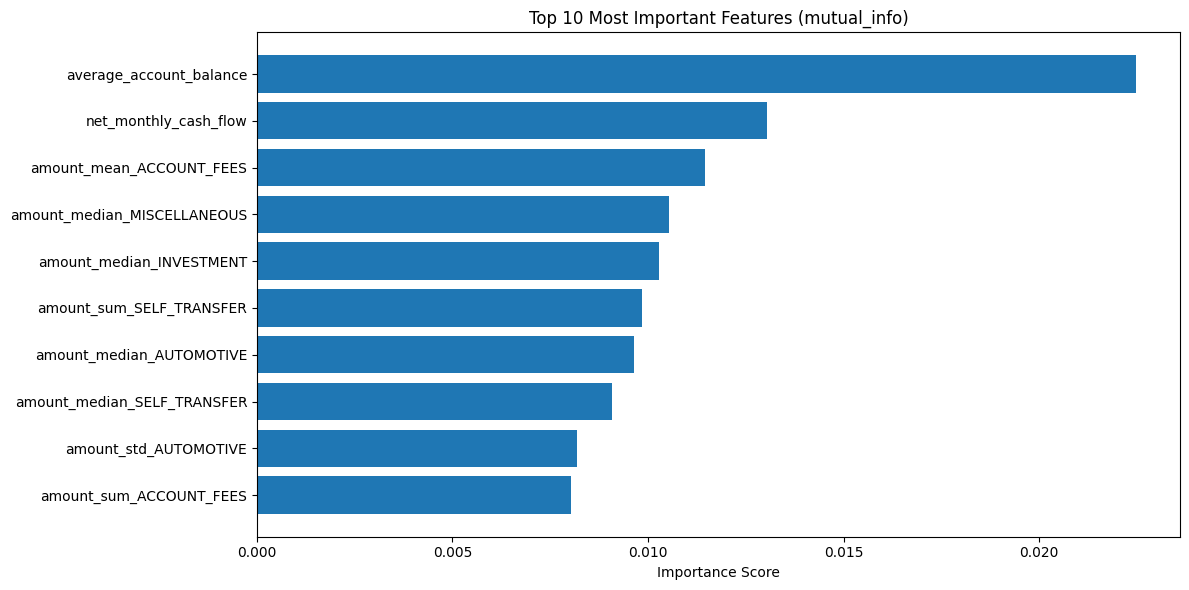

In [5]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=10)

## 4. Model Performance

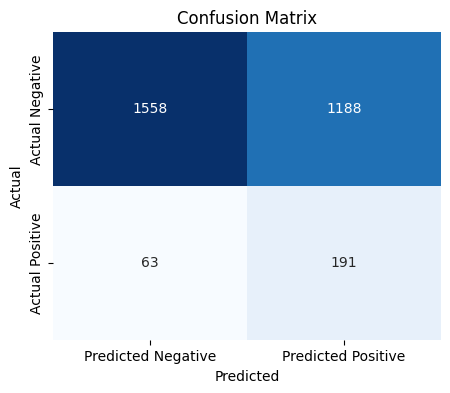

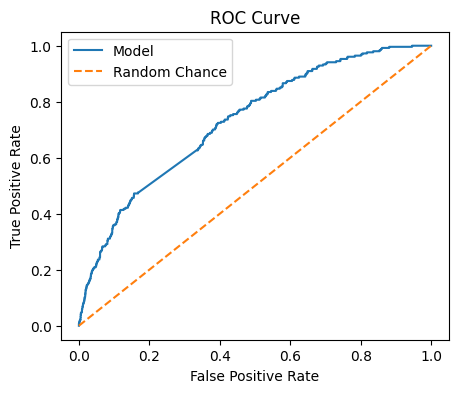

=== TEST METRICS ===
Accuracy: 0.583
ROC AUC Score: 0.7299407584976859
Balanced Accuracy: 0.6596696124929031

Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1558                1188
Actual Positive                  63                 191

=== TRAINING METRICS ===
Train Accuracy: 0.6232222222222222
Train ROC AUC: 0.9028678132158408
Train Balanced Accuracy: 0.7841623759209195


In [6]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)

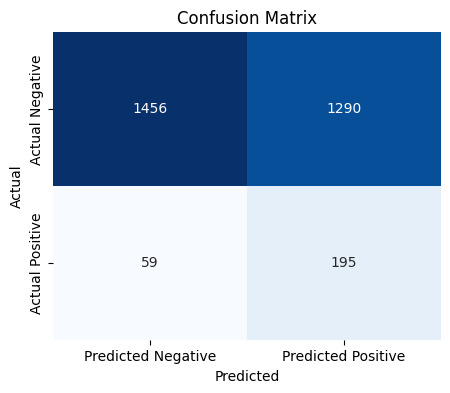

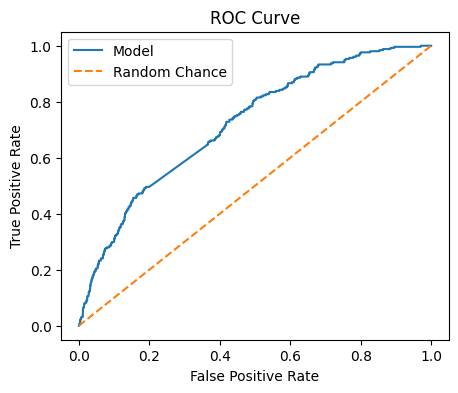

=== TEST METRICS ===
Accuracy: 0.5503333333333333
ROC AUC Score: 0.7197577292095589
Balanced Accuracy: 0.6489711591950496

Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                1456                1290
Actual Positive                  59                 195

=== TRAINING METRICS ===
Train Accuracy: 0.5801111111111111
Train ROC AUC: 0.8703259945673484
Train Balanced Accuracy: 0.7533902480549766


In [7]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)